# Import statements

In [1]:
import pickle
import numpy as np
import pandas as pd

In [2]:
import scipy
import sklearn
from scipy.stats import pearsonr
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from xgboost import plot_importance
from matplotlib import pyplot

In [3]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import shap
from math import sqrt
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
import seaborn as sns

/home/supadhyaya/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import tqdm as notebook_tqdm
from skopt import BayesSearchCV
import skopt
from skopt.space import Real, Categorical, Integer
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel

In [5]:
from platform import python_version

print(python_version())



3.10.12


In [6]:
!which python3

/usr/bin/python3


In [7]:
print(np.__version__)

1.26.3


# Define all functions

In [8]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(1, 10),
        'max_depth': Integer(1, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

#set parameter space for Random forest models
rf_space = {
    'n_estimators': Integer(50, 500),  # Number of trees
    'max_depth': Integer(3, 50),  # Maximum depth of trees
    'min_samples_split': Integer(2, 20),  # Minimum samples to split a node
    'min_samples_leaf': Integer(1, 10),  # Minimum samples per leaf node
    'max_features': Categorical(['sqrt']),  # Number of features to consider
    'bootstrap': Categorical([True]),  # Use bootstrapping
    'max_samples': Real(0.5, 1.0, 'uniform'),  # Fraction of samples used for training
}

#set parameter space for SVM models
svr_space = {
    'kernel': Categorical(['linear', 'rbf', 'poly', 'sigmoid']),
    'epsilon': Categorical([0.5, 1, 1.5, 2, 2.5, 3]),
}
 

In [9]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [10]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor()
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=24, scoring=None, n_jobs=-1,
        cv=5, verbose=1, random_state=42, n_points=6
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

def bayesian_rfr_search(X, y,rf_space):
    """
    Perform Bayesian hyperparameter tuning for Random forest using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        RFRegressor: Best Random Forest model with tuned parameters.
    """
    rfr = RandomForestRegressor()
    rf_bayes_search = BayesSearchCV(rfr, rf_space, n_iter=32, # specify how many iterations
                                    scoring=None, n_jobs=-1, cv=5, verbose=1, random_state=42, n_points=7 # Use all CPU cores
                                   )
    
    rf_bayes_search.fit(X, y.ravel())
    
    print("Best RF Parameters:",  rf_bayes_search.best_params_)
    
    best_params = rf_bayes_search.best_params_
    best_rfreg = RandomForestRegressor(**best_params)

    return best_rfreg

#TO RUN - best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

def bayesian_svr_search(X, y, svr_space):
    """
    Perform Bayesian hyperparameter tuning for SVR using BayesSearchCV.

    Parameters:
        X (array-like): Feature set.
        y (array-like): Target variable.
        svr_space (dict): Hyperparameter search space for SVR.

    Returns:
        SVR: Best SVR model with tuned parameters.
    """
    svr = SVR()
    svr_bayes_search = BayesSearchCV(
        svr,
        svr_space,
        n_iter=10,
        scoring=None,
        n_jobs=-1,
        cv=5,
        verbose=1,
        random_state=42,
        n_points=2
    )

    svr_bayes_search.fit(X, y.ravel())
    
    print("Best SVR Parameters:", svr_bayes_search.best_params_)
    
    best_params = svr_bayes_search.best_params_
    best_svr = SVR(**best_params)

    return best_svr

#TO RUN - best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

In [11]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, x, y, k):
    #model: xgboost model, should be with the best params available
    #x: input data (eg. all samples and SNPS)
    #y: labels
    #k: number of folds for cross validation
    cv = KFold(n_splits=k,shuffle=True)
  #  fig1 = plt.figure(figsize=[12,12])

   # tprs = []
   # aucs = []
    results = []
   # mean_fpr = np.linspace(0,1,100)
    low = 100
    best = m
    i = 1
    for train,test in cv.split(x,y):
        #print(y[test])
        m.fit(x[train],y[train].ravel())
        print("fitting done. Processing fold accuracy + checking best model")
        #predictions = [round(value) for value in y_pred]
        #sees how accurate the model was when testing the test set
        all_preds = [x for x in m.predict(x[test])]
        ss = sqrt(mean_squared_error(all_preds, y[test]))
        rr = r2_score(all_preds, y[test])
        mm = np.mean(y[test])
        error_mean = ((ss/mm)*100)
        print("R^2 Value is: " + str(rr))
        print("RMSE for dataset is:" +str(ss) + "& mean of this fold is " + str(mm))
        print("this is "+ str((ss/mm)*100) + "% of the mean pheno data")
        if(error_mean < low):
            low = error_mean
            best = m
        results.append(error_mean)
        i= i+1
    print("Training Testing Accuracy: %.2f%% (%.2f%%)" % (np.mean(results), np.std(results)))
    return best

#TO RUN - best_model_xgb = eval_k_fold(model, X, y, 10) or best_model_rfr = eval_k_fold(model, X, y, 10)

In [12]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('SNP Label')
    plt.xlabel('Relative F_Score (GAIN)')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [13]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = [x for x in best_model.predict(X_holdout)]

    # Compute performance metrics
    ss = sqrt(mean_squared_error(all_preds, y_holdout))
    rr = r2_score(all_preds, y_holdout)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100

    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")

    # Prepare data for residual plot
    y_holdout = y_holdout.ravel()
    plot_x, plot_y = [], []

    for counter, actual in enumerate(y_holdout):
        if counter <= 5:  # Print first 5 examples
            print(counter, actual, all_preds[counter])
        if all_preds[counter] > 1:
            plot_x.append(actual)
            plot_y.append(all_preds[counter])

    # Create a DataFrame for plotting
    thisplot = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

    # Generate regression plot
    plt.figure(figsize=(8, 6))
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('XGBoost Predicted vs Actual')
    plt.show()


    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [14]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

# XGBoost feature selection

In [16]:
tt_data = pd.read_pickle("pickle_files/training_data_prt.pkl")
tt_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0,0,0,0,0,0,0,0,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014_HeNan_2014,s1014,0,0,0,0,0,0,0,0,0,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


In [17]:
tt_bbd_snps = tt_data.iloc[:, 1:251229]
tt_bbd_snps.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52241824,Chr20_52246739,Chr20_52247340,Chr20_52249163,Chr20_52251920,Chr20_52255532,Chr20_52261413,Chr20_52266575,Chr20_52267177,Chr20_52267897
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s100_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s1014_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
s1014_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
s101_HeiLongJiang_2014,0,0,1,0,0,1,1,0,0,0,...,2,0,1,0,0,2,2,0,2,0


In [18]:
tt_bbd_snps_dupe = tt_data.iloc[:, 1:251229]
tt_bbd_snps_dupe.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52241824,Chr20_52246739,Chr20_52247340,Chr20_52249163,Chr20_52251920,Chr20_52255532,Chr20_52261413,Chr20_52266575,Chr20_52267177,Chr20_52267897
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s100_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,2,2,0,2,0
s1014_BeiJing_2013,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
s1014_HeNan_2014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,0
s101_HeiLongJiang_2014,0,0,1,0,0,1,1,0,0,0,...,2,0,1,0,0,2,2,0,2,0


In [20]:
tt_y = tt_data.iloc[:, 251239:]
tt_y.head()

,PRT
new_line,
s100_BeiJing_2013,340.553
s100_HeNan_2014,358.104
s1014_BeiJing_2013,366.116
s1014_HeNan_2014,326.667
s101_HeiLongJiang_2014,385.915


In [21]:
cov = tt_data.iloc[:,-10:]
cov.head()

,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,
s100_BeiJing_2013,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100_HeNan_2014,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014_BeiJing_2013,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014_HeNan_2014,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101_HeiLongJiang_2014,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(tt_bbd_snps, tt_y, test_size=0.1, random_state=42)

In [ ]:
#Ran this is an isolated high mem job and got the bets params
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

In [22]:
best_params = {
    'colsample_bylevel': 0.0615722825888655,
    'colsample_bytree': 0.3961822407276705,
    'gamma': 0.0020899839106062385,
    'learning_rate': 0.15678005750702292,
    'max_delta_step': 0,
    'max_depth': 26,
    'min_child_weight': 6,
    'n_estimators': 200,
    'reg_alpha': 0.007412583927433561,
    'reg_lambda': 1000.0,
    'subsample': 0.32214079047287686                   
}

# Run the model with the best parameters
model = xgb.XGBRegressor(**best_params)

In [23]:
#tt_bbd_snps = tt_bbd_snps.to_numpy()
#tt_y = tt_y.to_numpy() 
#Fit the modle on the entire training training set
model.fit(tt_bbd_snps, tt_y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=0.0615722825888655, colsample_bynode=None,
             colsample_bytree=0.3961822407276705, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.0020899839106062385, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.15678005750702292, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=0,
             max_depth=26, max_leaves=None, min_child_weight=6, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [24]:
#if you wan tto use the default feature importance
importances = model.feature_importances_
print(importances)
print("Median importance:", np.median(importances))
print("Features kept:", selector.get_support().sum(), "out of", len(importances))

[0. 0. 0. ... 0. 0. 0.]
Median importance: 0.0


NameError: name 'selector' is not defined

<Figure size 2000x2000 with 0 Axes>

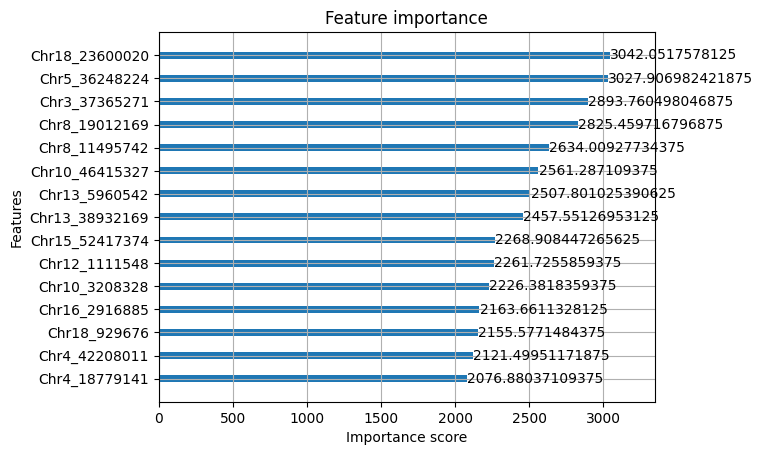

In [27]:
plt.figure(figsize = (20, 20))
plot_importance(model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

In [38]:
booster = model.get_booster()
importances = booster.get_score(importance_type='gain')
feature_names = booster.feature_names
importances_array = np.array([importances.get(f, 0.) for f in feature_names])

In [39]:
importances_array

array([0., 0., 0., ..., 0., 0., 0.])

In [40]:
print("Max importance:", np.max(importances_array))
print("Min importance:", np.min(importances_array))
print("Mean importance:", np.mean(importances_array))
print("Median importance:", np.median(importances_array))

Max importance: 3042.0517578125
Min importance: 0.0
Mean importance: 3.097879540363282
Median importance: 0.0


In [41]:
print("Features with gain > 0:", np.sum(importances_array > 0))
print("Features with gain > mean:", np.sum(importances_array > np.mean(importances_array)))
print("Features with gain > 2000:", np.sum(importances_array > 100))

Features with gain > 0: 4480
Features with gain > mean: 4316
Features with gain > 2000: 2038


In [42]:
top_n = 1000 # Choose a number based on the max value and median values from abive
top_indices = np.argsort(importances_array)[::-1][:top_n]  # Sort in descending order and take first 1000
selected_features = np.array(feature_names)[top_indices]
new_data = tt_bbd_snps[selected_features]

In [36]:
# If using a threshold like mean or median or a custom thresold then use this
threshold = np.median(importances_array)
selected_mask = importances_array > threshold
selected_features = np.array(feature_names)[selected_mask]
new_data = tt_bbd_snps[selected_features]

In [43]:
new_data.head()

,Chr18_23600020,Chr5_36248224,Chr3_37365271,Chr8_19012169,Chr8_11495742,Chr10_46415327,Chr13_5960542,Chr13_38932169,Chr15_52417374,Chr12_1111548,...,Chr10_24459648,Chr9_49958169,Chr1_7217576,Chr14_17499839,Chr7_5661467,Chr18_7976151,Chr3_32202833,Chr3_40181839,Chr6_46052745,Chr15_44305656
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,0,2,0,0,0,2,0,2,0,0,...,0,0,0,0,0,0,0,0,1,0
s100_HeNan_2014,0,2,0,0,0,2,0,2,0,0,...,0,0,0,0,0,0,0,0,1,0
s1014_BeiJing_2013,2,2,0,2,2,0,0,2,1,2,...,1,0,0,0,0,0,0,0,0,0
s1014_HeNan_2014,2,2,0,2,2,0,0,2,1,2,...,1,0,0,0,0,0,0,0,0,0
s101_HeiLongJiang_2014,0,0,0,0,0,2,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [24]:
# Select important features and tranform (can't use this, as it use weight as importance type)
selector = SelectFromModel(model, prefit=True, threshold='median')
X_selected = selector.transform(tt_bbd_snps)

/home/supadhyaya/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [25]:
# Get the names of the selected features
selected_features = tt_bbd_snps.columns[selector.get_support()]

In [29]:
# Create a new df with only the selected features
new_data = pd.DataFrame(X_selected, columns=selected_features, index=tt_bbd_snps.index)

In [157]:
new_data.head()

,Chr1_241970,Chr1_1444930,Chr1_1945717,Chr1_3234577,Chr1_3445775,Chr1_3504427,Chr1_7977377,Chr1_9872220,Chr1_10203439,Chr1_11136926,...,Chr20_35671210,Chr20_36007112,Chr20_38952655,Chr20_39880849,Chr20_40457173,Chr20_42887442,Chr20_44416558,Chr20_44426687,Chr20_47728999,Chr20_50892784
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,1,0,0,0,0,0,0,0,0,0,...,0,0,2,2,0,0,0,0,0,0
s100_HeNan_2014,1,0,0,0,0,0,0,0,0,0,...,0,0,2,2,0,0,0,0,0,0
s100_HeNan_2015,1,0,0,0,0,0,0,0,0,0,...,0,0,2,2,0,0,0,0,0,0
s1014_BeiJing_2013,0,0,0,0,2,0,2,0,0,0,...,0,1,0,0,0,2,0,2,1,0
s1014_HeNan_2014,0,0,0,0,2,0,2,0,0,0,...,0,1,0,0,0,2,0,2,1,0


In [44]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100_BeiJing_2013 to s99_BeiJing_2013
Columns: 1000 entries, Chr18_23600020 to Chr15_44305656
dtypes: int64(1000)
memory usage: 8.4+ MB


In [45]:
fs_data = pd.merge(new_data, cov, on='new_line', how='outer', indicator=False)
fs_data.head()

,Chr18_23600020,Chr5_36248224,Chr3_37365271,Chr8_19012169,Chr8_11495742,Chr10_46415327,Chr13_5960542,Chr13_38932169,Chr15_52417374,Chr12_1111548,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,0,2,0,0,0,2,0,2,0,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100_HeNan_2014,0,2,0,0,0,2,0,2,0,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014_BeiJing_2013,2,2,0,2,2,0,0,2,1,2,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014_HeNan_2014,2,2,0,2,2,0,0,2,1,2,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101_HeiLongJiang_2014,0,0,0,0,0,2,2,0,0,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


In [47]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100_BeiJing_2013 to s99_BeiJing_2013
Columns: 1010 entries, Chr18_23600020 to PRT
dtypes: float64(4), int64(1006)
memory usage: 8.4+ MB


In [48]:
fs_data['Line'] = fs_data.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
fs_data = fs_data.reset_index(drop=True).set_index('Line')
fs_data.head()

,Chr18_23600020,Chr5_36248224,Chr3_37365271,Chr8_19012169,Chr8_11495742,Chr10_46415327,Chr13_5960542,Chr13_38932169,Chr15_52417374,Chr12_1111548,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,2,0,0,0,2,0,2,0,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100,0,2,0,0,0,2,0,2,0,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014,2,2,0,2,2,0,0,2,1,2,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014,2,2,0,2,2,0,0,2,1,2,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101,0,0,0,0,0,2,2,0,0,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


In [49]:
fs_data.to_pickle("fs_prt_xgboost_training_data.pkl")

# All covariates

In [73]:
tt_data = pd.read_pickle("fs_prt_xgboost_training_data.pkl")
tt_data.head()

,Chr18_23600020,Chr5_36248224,Chr3_37365271,Chr8_19012169,Chr8_11495742,Chr10_46415327,Chr13_5960542,Chr13_38932169,Chr15_52417374,Chr12_1111548,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,2,0,0,0,2,0,2,0,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100,0,2,0,0,0,2,0,2,0,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014,2,2,0,2,2,0,0,2,1,2,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014,2,2,0,2,2,0,0,2,1,2,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101,0,0,0,0,0,2,2,0,0,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


In [74]:
tt_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 1010 entries, Chr18_23600020 to PRT
dtypes: float64(4), int64(1006)
memory usage: 8.4+ MB


In [75]:
tt_y = tt_data.iloc[:, 1009:]
tt_y.head()

,PRT
Line,
s100,340.553
s100,358.104
s1014,366.116
s1014,326.667
s101,385.915


In [76]:
tt_all= tt_data.drop(['PRT'], axis=1)
tt_all.head()

,Chr18_23600020,Chr5_36248224,Chr3_37365271,Chr8_19012169,Chr8_11495742,Chr10_46415327,Chr13_5960542,Chr13_38932169,Chr15_52417374,Chr12_1111548,...,Chr15_44305656,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,2,0,0,0,2,0,2,0,0,...,0,61,6.26667,9.5000,154.700,1,0,0,0,1
s100,0,2,0,0,0,2,0,2,0,0,...,0,37,7.19333,10.2200,130.000,0,1,0,0,1
s1014,2,2,0,2,2,0,0,2,1,2,...,0,77,7.76667,10.3667,111.733,1,0,0,0,1
s1014,2,2,0,2,2,0,0,2,1,2,...,0,42,7.78667,11.8200,73.000,0,1,0,0,1
s101,0,0,0,0,0,2,2,0,0,0,...,0,62,10.22000,14.2800,95.700,0,0,1,0,1


In [77]:
tt_all_dupe= tt_data.drop(['PRT'], axis=1)
tt_all_dupe.head()

,Chr18_23600020,Chr5_36248224,Chr3_37365271,Chr8_19012169,Chr8_11495742,Chr10_46415327,Chr13_5960542,Chr13_38932169,Chr15_52417374,Chr12_1111548,...,Chr15_44305656,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,2,0,0,0,2,0,2,0,0,...,0,61,6.26667,9.5000,154.700,1,0,0,0,1
s100,0,2,0,0,0,2,0,2,0,0,...,0,37,7.19333,10.2200,130.000,0,1,0,0,1
s1014,2,2,0,2,2,0,0,2,1,2,...,0,77,7.76667,10.3667,111.733,1,0,0,0,1
s1014,2,2,0,2,2,0,0,2,1,2,...,0,42,7.78667,11.8200,73.000,0,1,0,0,1
s101,0,0,0,0,0,2,2,0,0,0,...,0,62,10.22000,14.2800,95.700,0,0,1,0,1


# Run models

In [78]:
X_train, X_test, y_train, y_test = train_test_split(tt_all, tt_y, test_size=0.1, random_state=42)

In [79]:
X_train.head()

,Chr18_23600020,Chr5_36248224,Chr3_37365271,Chr8_19012169,Chr8_11495742,Chr10_46415327,Chr13_5960542,Chr13_38932169,Chr15_52417374,Chr12_1111548,...,Chr15_44305656,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s174,0,2,0,2,2,0,0,0,1,0,...,0,35,7.18000,9.62667,42.700,0,1,0,1,0
s623,2,2,2,0,0,0,0,2,0,1,...,0,57,8.40000,9.20000,63.100,1,0,0,1,0
s237,0,2,2,0,0,2,2,1,0,2,...,0,45,7.43333,10.36670,106.467,1,0,0,1,0
s730,2,2,2,2,0,0,2,0,0,0,...,0,54,10.78670,15.87330,55.700,0,0,1,1,0
s195,0,2,2,0,0,2,0,0,0,2,...,0,64,8.54667,13.18000,44.940,0,0,1,1,0


In [80]:
X_train = X_train.to_numpy()

In [81]:
y_train = y_train.to_numpy()

In [82]:
print("Any NaN in y:", np.isnan(y_train).any())
print("Any inf in y:", np.isinf(y_train).any())
print("Max value in y:", np.max(y_train))
print("Any NaN in X:", np.isnan(X_train).any())
print("Any inf in X:", np.isinf(X_train).any())

Any NaN in y: False
Any inf in y: False
Max value in y: 458.215
Any NaN in X: False
Any inf in X: False


In [83]:
print(y_train.dtype)

float64


In [84]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 1.0), ('colsample_bytree', 0.01), ('gamma', 1e-09), ('learning_rate', 1.0), ('max_delta_step', 20), ('max_depth', 37), ('min_child_weight', 4), ('n_estimators', 200), ('reg_alpha', 1e-09), ('reg_lambda', 1000.0), ('subsample', 1.0)])


In [85]:
tt_all = tt_all.to_numpy()
tt_y = tt_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, tt_all, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.930330255567559
RMSE for dataset is:22.320473021645785& mean of this fold is 356.10867272727285
this is 6.267882455853583% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.6290553973074031
RMSE for dataset is:21.355667755688636& mean of this fold is 353.39405454545454
this is 6.0430184042447745% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.5061877448040646
RMSE for dataset is:19.341253985527405& mean of this fold is 349.4572181818181
this is 5.534655740166854% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.9305784681966143
RMSE for dataset is:20.347458279881955& mean of this fold is 354.4430545454545
this is 5.740684721830981% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.203759262563647
RMSE for

In [86]:
pickle.dump(best_xgbr_model, open("xgboost_allfeats_xgbr_prt.pickle.dat", "wb"))
#best_xgbr_model = pickle.load(open("gwas_top1_allfeats_xgbr_bbd.pickle.dat", "rb"))

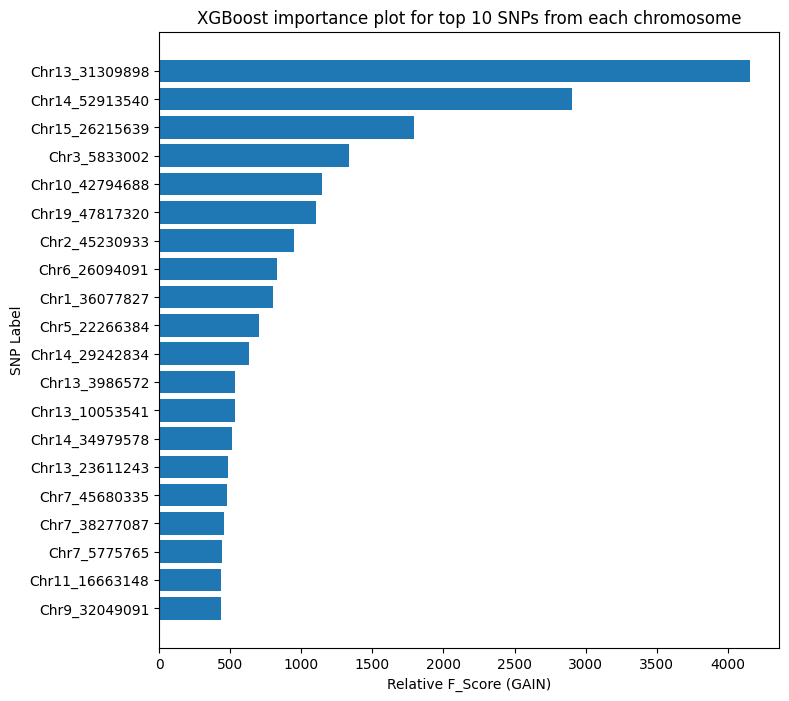

In [87]:
f_names = ['f' + str(i) for i in range(len(tt_all_dupe.columns))]
my_dict = best_xgbr_model.get_booster().get_score(importance_type="gain")

new_dict = {}
for key in my_dict:
    ind = f_names.index(key)
    new_dict[tt_all_dupe.columns[ind]] = my_dict[key]

new_fi = pd.Series(new_dict)
df = new_fi.to_frame()
df = df.rename(columns = {0:'F_Score(GAIN)'})

#plot dataframe now with top 20 SNPS
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
figure(num=None, figsize=(8, 8), dpi=100, facecolor='w', edgecolor='k')
indexes = df.nlargest(20, "F_Score(GAIN)").index
values = df.nlargest(20, "F_Score(GAIN)").values.ravel()
indexes = indexes[::-1]
values = values[::-1]
plt.barh(indexes, values)
plt.title('XGBoost importance plot for top 10 SNPs from each chromosome')
plt.ylabel('SNP Label')
plt.xlabel('Relative F_Score (GAIN)')
plt.savefig('XGBoost importance plot for top 10 SNPs from each chromosome.png')

In [88]:
explainer = shap.Explainer(best_xgbr_model)

In [89]:
shap_values = explainer(tt_all_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

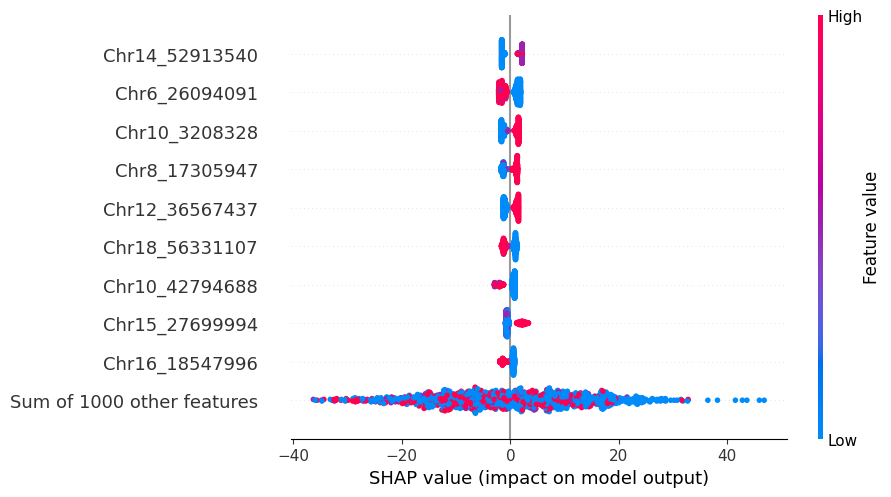

In [90]:
shap.plots.beeswarm(shap_values, show=False)

In [91]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [92]:
holdout_data = holdout_data.set_index('Line')

In [93]:
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102,2,0,0,0,0,0,0,1,0,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110,0,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112,0,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113,0,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [94]:
X_holdout = holdout_data.iloc[:, 0:251238]

In [95]:
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [96]:
y_holdout = holdout_data.iloc[:, 251238:]

In [97]:
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [98]:
# Ensure both trainjg and holdout datasets have the same columns
tt_all_dupe, X_holdout = tt_all_dupe.align(X_holdout, join='inner', axis=1)

In [99]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 1009 entries, Chr18_23600020 to landrace
dtypes: float64(3), int64(1006)
memory usage: 2.1+ MB


In [100]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: -1.81
RMSE of Holdout: 23.84
Mean of Holdout: 355.60
This is 6.70% of the mean pheno data
0 355.712 365.58078
1 344.136 360.78198
2 351.481 375.55573
3 353.611 375.23666
4 390.342 370.09418
5 358.958 357.33017


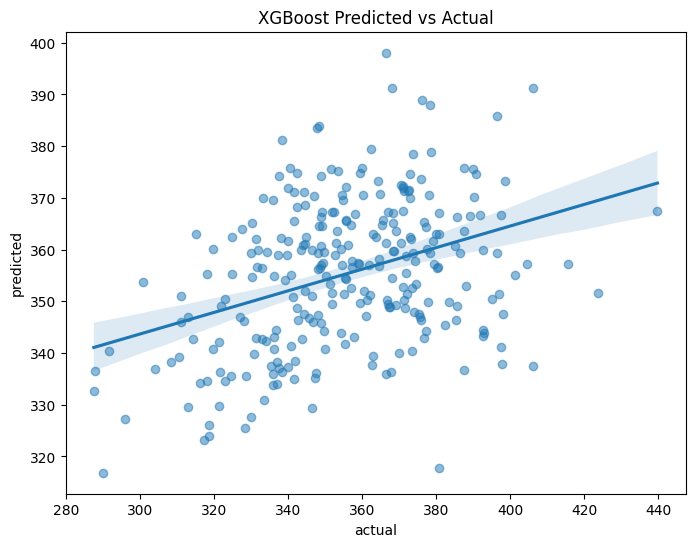

In [101]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [102]:
  # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])


0 355.712 365.58078
1 344.136 360.78198
2 351.481 375.55573
3 353.611 375.23666
4 390.342 370.09418
5 358.958 357.33017


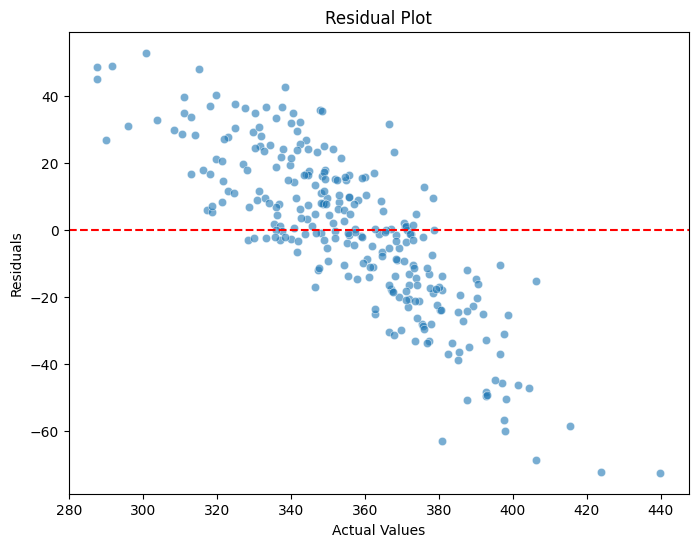

In [103]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot
plt.show()

In [104]:
#### RF models

In [105]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 38), ('max_features', 'sqrt'), ('max_samples', 0.589390618861442), ('min_samples_leaf', 1), ('min_samples_split', 12), ('n_estimators', 126)])


In [106]:
#gwas_all = gwas_all.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, tt_all, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.1244589496853576
RMSE for dataset is:22.55710471999737& mean of this fold is 353.80871818181816
this is 6.375508448722153% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.1898537837902925
RMSE for dataset is:22.144168098314022& mean of this fold is 353.52997272727276
this is 6.263731453230112% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.859785779662327
RMSE for dataset is:20.118610289170146& mean of this fold is 352.0871000000001
this is 5.714100371518906% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.2294333309286296
RMSE for dataset is:19.83778742586766& mean of this fold is 355.06659090909096
this is 5.58706111298058% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.0205847261361765
RMSE for d

In [107]:
pickle.dump(best_rfr_model, open("xgboost_allfeats_rfr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -5.22
RMSE of Holdout: 23.28
Mean of Holdout: 355.60
This is 6.55% of the mean pheno data
0 355.712 354.1750642608791
1 344.136 357.2910557147535
2 351.481 361.6169371552667
3 353.611 368.36870804065165
4 390.342 362.0350654990304
5 358.958 350.6201610624456


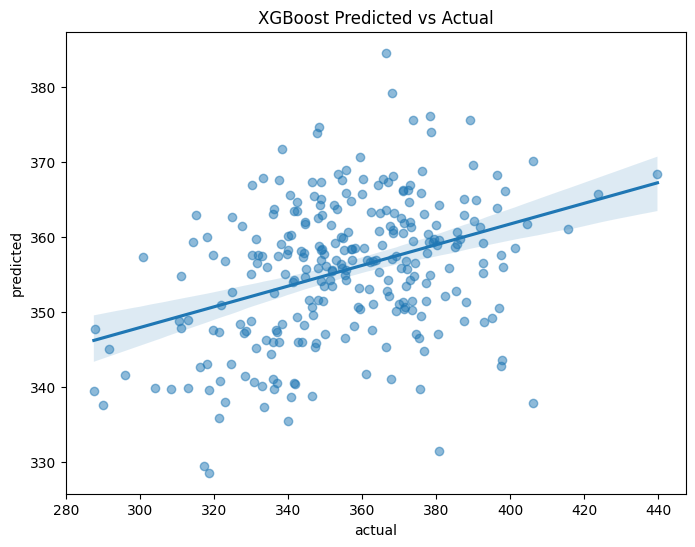

In [108]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [109]:
from sklearn.svm import SVR
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2), ('kernel', 'poly')])


In [110]:
best_svr_model = eval_k_fold(best_svreg, tt_all, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -56.33844860565778
RMSE for dataset is:24.456358376590654& mean of this fold is 355.72355454545453
this is 6.875102327098108% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -47.434653293366424
RMSE for dataset is:24.61238081654972& mean of this fold is 348.7154909090909
this is 7.058011891696% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -71.31393812791356
RMSE for dataset is:25.828167905368755& mean of this fold is 357.33120909090906
this is 7.228075031867082% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -62.83687410194894
RMSE for dataset is:25.159119330344975& mean of this fold is 355.2379818181819
this is 7.0823280780887705% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -51.665441358452426
RMSE for data

In [111]:
pickle.dump(best_svr_model, open("xgboost_allfeats_svr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -73.05
RMSE of Holdout: 24.71
Mean of Holdout: 355.60
This is 6.95% of the mean pheno data
0 355.712 352.49732532004975
1 344.136 352.8912493070955
2 351.481 357.8968013516215
3 353.611 357.6711225948725
4 390.342 354.75923553179035
5 358.958 353.39244718363904


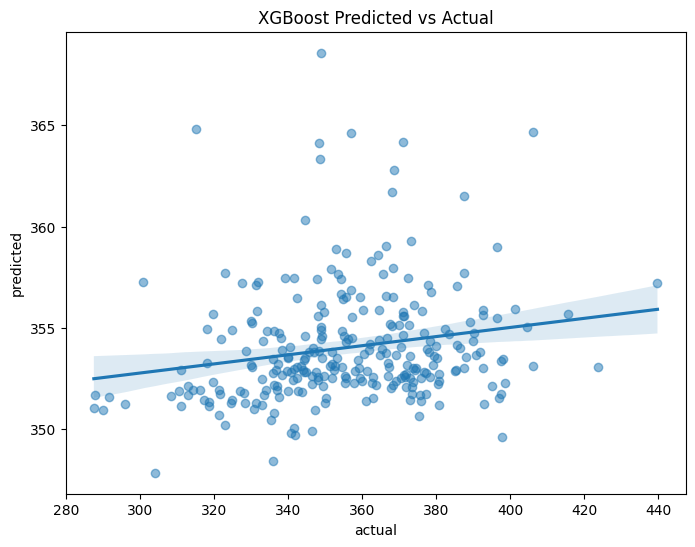

In [112]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

# GWAS only SNPs

In [113]:
tt_bbd_snps = fs_data.iloc[:, 0:1000]
tt_bbd_snps.head()

,Chr18_23600020,Chr5_36248224,Chr3_37365271,Chr8_19012169,Chr8_11495742,Chr10_46415327,Chr13_5960542,Chr13_38932169,Chr15_52417374,Chr12_1111548,...,Chr10_24459648,Chr9_49958169,Chr1_7217576,Chr14_17499839,Chr7_5661467,Chr18_7976151,Chr3_32202833,Chr3_40181839,Chr6_46052745,Chr15_44305656
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,2,0,0,0,2,0,2,0,0,...,0,0,0,0,0,0,0,0,1,0
s100,0,2,0,0,0,2,0,2,0,0,...,0,0,0,0,0,0,0,0,1,0
s1014,2,2,0,2,2,0,0,2,1,2,...,1,0,0,0,0,0,0,0,0,0
s1014,2,2,0,2,2,0,0,2,1,2,...,1,0,0,0,0,0,0,0,0,0
s101,0,0,0,0,0,2,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [114]:
tt_bbd_snps_dupe = fs_data.iloc[:, 0:1000]
tt_bbd_snps_dupe.head()

,Chr18_23600020,Chr5_36248224,Chr3_37365271,Chr8_19012169,Chr8_11495742,Chr10_46415327,Chr13_5960542,Chr13_38932169,Chr15_52417374,Chr12_1111548,...,Chr10_24459648,Chr9_49958169,Chr1_7217576,Chr14_17499839,Chr7_5661467,Chr18_7976151,Chr3_32202833,Chr3_40181839,Chr6_46052745,Chr15_44305656
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,2,0,0,0,2,0,2,0,0,...,0,0,0,0,0,0,0,0,1,0
s100,0,2,0,0,0,2,0,2,0,0,...,0,0,0,0,0,0,0,0,1,0
s1014,2,2,0,2,2,0,0,2,1,2,...,1,0,0,0,0,0,0,0,0,0
s1014,2,2,0,2,2,0,0,2,1,2,...,1,0,0,0,0,0,0,0,0,0
s101,0,0,0,0,0,2,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [115]:
tt_y = tt_data.iloc[:, 1009:]
tt_y.head()

,PRT
Line,
s100,340.553
s100,358.104
s1014,366.116
s1014,326.667
s101,385.915


# Run models

In [116]:
X_train, X_test, y_train, y_test = train_test_split(tt_bbd_snps, tt_y, test_size=0.1, random_state=42)

In [117]:
X_train.head()

,Chr18_23600020,Chr5_36248224,Chr3_37365271,Chr8_19012169,Chr8_11495742,Chr10_46415327,Chr13_5960542,Chr13_38932169,Chr15_52417374,Chr12_1111548,...,Chr10_24459648,Chr9_49958169,Chr1_7217576,Chr14_17499839,Chr7_5661467,Chr18_7976151,Chr3_32202833,Chr3_40181839,Chr6_46052745,Chr15_44305656
Line,,,,,,,,,,,,,,,,,,,,,
s174,0,2,0,2,2,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
s623,2,2,2,0,0,0,0,2,0,1,...,0,0,2,0,0,0,0,0,0,0
s237,0,2,2,0,0,2,2,1,0,2,...,0,0,0,0,0,0,0,0,0,0
s730,2,2,2,2,0,0,2,0,0,0,...,0,0,0,1,0,1,0,0,0,0
s195,0,2,2,0,0,2,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0


In [118]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [119]:
#Ran this is an isolated high mem job and got the bets params
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.2539054279115306), ('colsample_bytree', 0.4809576696342559), ('gamma', 3.169288611647266e-05), ('learning_rate', 0.052759557217512985), ('max_delta_step', 14), ('max_depth', 9), ('min_child_weight', 3), ('n_estimators', 138), ('reg_alpha', 2.873712301786629e-05), ('reg_lambda', 8.3570980818864e-09), ('subsample', 0.06877324348114687)])


In [120]:
tt_bbd_snps = tt_bbd_snps.to_numpy()
tt_y = tt_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, tt_bbd_snps, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.9893167673638474
RMSE for dataset is:20.297633995442098& mean of this fold is 354.72876363636357
this is 5.722015262413124% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.978667810801526
RMSE for dataset is:20.1898901159929& mean of this fold is 352.42896363636356
this is 5.7287828751852645% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.355845351530496
RMSE for dataset is:23.431349195023227& mean of this fold is 355.639
this is 6.58852071764436% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.456534254815796
RMSE for dataset is:23.7644107192328& mean of this fold is 353.17794545454547
this is 6.728735761981863% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.9334185429241484
RMSE for dataset is:20.

In [121]:
pickle.dump(best_xgbr_model, open("xgboost_onlysnps_xgbr_prt.pickle.dat", "wb"))

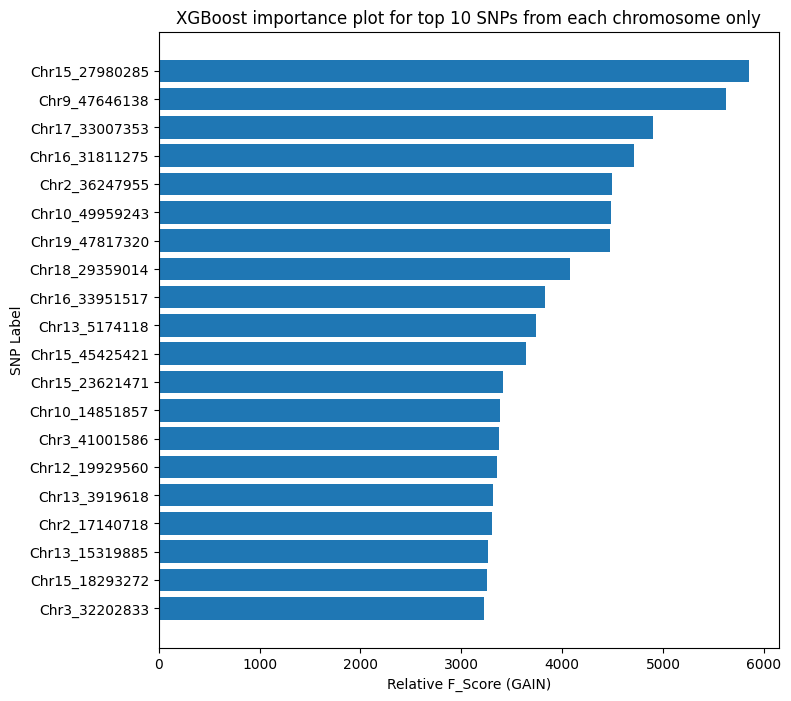

In [122]:
f_names = ['f' + str(i) for i in range(len(tt_bbd_snps_dupe.columns))]
my_dict = best_xgbr_model.get_booster().get_score(importance_type="gain")

new_dict = {}
for key in my_dict:
    ind = f_names.index(key)
    new_dict[tt_bbd_snps_dupe.columns[ind]] = my_dict[key]

new_fi = pd.Series(new_dict)
df = new_fi.to_frame()
df = df.rename(columns = {0:'F_Score(GAIN)'})

#plot dataframe now with top 20 SNPS
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
figure(num=None, figsize=(8, 8), dpi=100, facecolor='w', edgecolor='k')
indexes = df.nlargest(20, "F_Score(GAIN)").index
values = df.nlargest(20, "F_Score(GAIN)").values.ravel()
indexes = indexes[::-1]
values = values[::-1]
plt.barh(indexes, values)
plt.title('XGBoost importance plot for top 10 SNPs from each chromosome only')
plt.ylabel('SNP Label')
plt.xlabel('Relative F_Score (GAIN)')
plt.savefig('XGBoost importance plot for top 10 SNPs from each chromosome only.png')

In [123]:
explainer = shap.Explainer(best_xgbr_model)

In [124]:
shap_values = explainer(tt_bbd_snps_dupe)

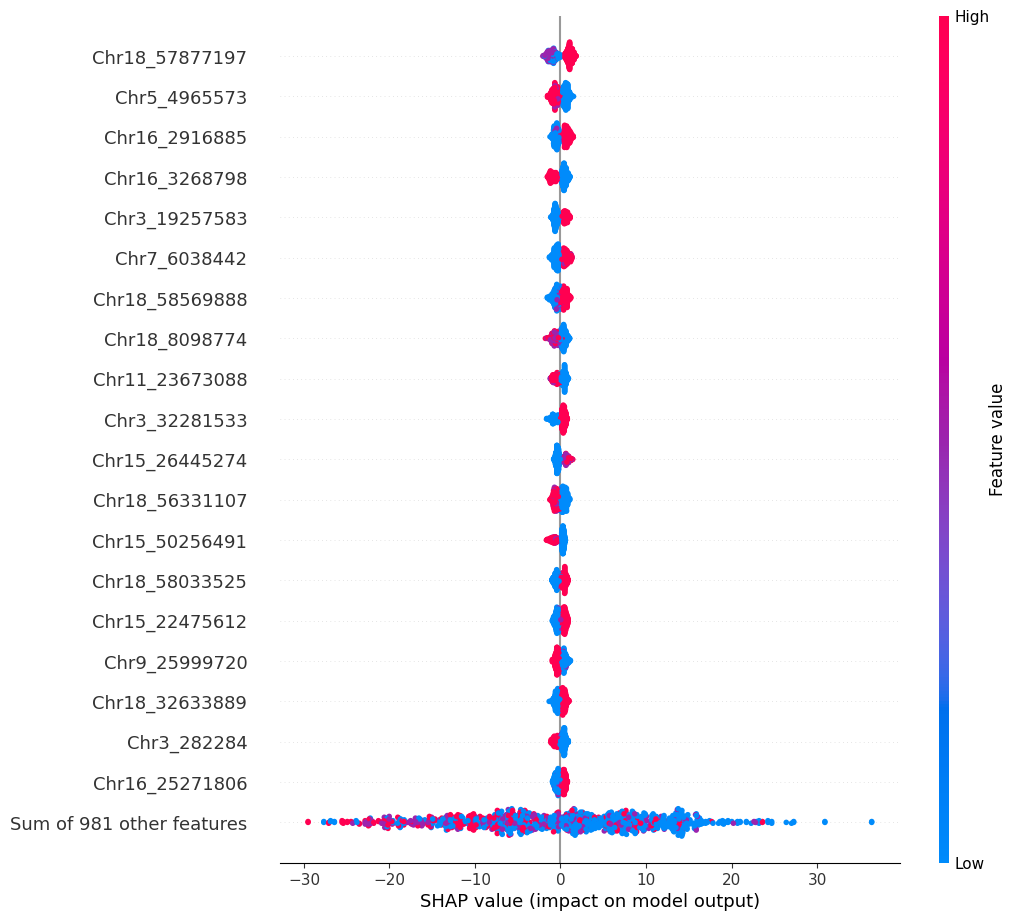

In [125]:
shap.plots.beeswarm(shap_values,20, plot_size=[10,11])


In [126]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [127]:
holdout_data = holdout_data.set_index('Line')

In [128]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [129]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [130]:
# Ensure both trainjg and holdout datasets have the same columns
tt_bbd_snps_dupe, X_holdout = tt_bbd_snps_dupe.align(X_holdout, join='inner', axis=1)

In [131]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 1000 entries, Chr18_23600020 to Chr15_44305656
dtypes: int64(1000)
memory usage: 2.1+ MB


In [132]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: -2.54
RMSE of Holdout: 23.36
Mean of Holdout: 355.60
This is 6.57% of the mean pheno data
0 355.712 356.5577
1 344.136 366.71362
2 351.481 359.28528
3 353.611 366.08823
4 390.342 367.24466
5 358.958 354.90826


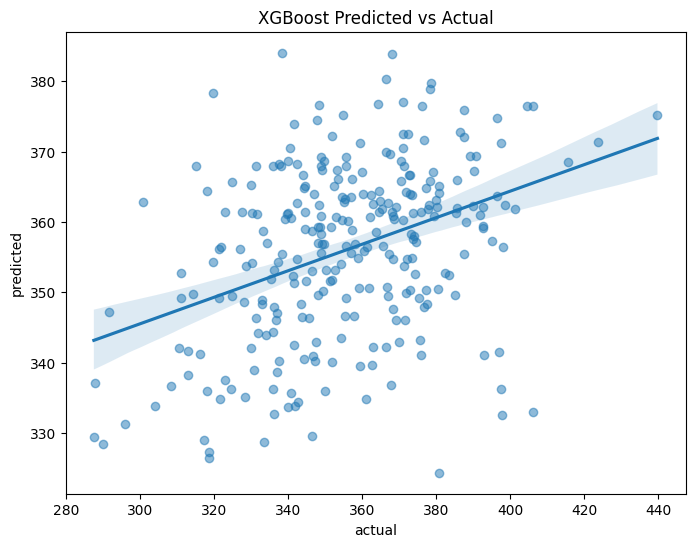

In [133]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [ ]:
#### RF models

In [134]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 42), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 3), ('min_samples_split', 14), ('n_estimators', 500)])


In [ ]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 7), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 1), ('min_samples_split', 20), ('n_estimators', 124)])

In [135]:
#tt_snps = gwas_snps.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, tt_bbd_snps, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.3237545896591407
RMSE for dataset is:19.170841364684133& mean of this fold is 353.39104545454546
this is 5.424823750139407% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.803437821100224
RMSE for dataset is:24.91848179564806& mean of this fold is 354.9923818181818
this is 7.019441281534509% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.148232609126355
RMSE for dataset is:22.229064200518287& mean of this fold is 352.3772454545454
this is 6.308314310092338% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.915284328589279
RMSE for dataset is:20.995874740653598& mean of this fold is 356.65259999999995
this is 5.886926028480825% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.7498241034434896
RMSE for da

In [136]:
pickle.dump(best_rfr_model, open("xgboost_onlysnps_rfr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -4.33
RMSE of Holdout: 23.34
Mean of Holdout: 355.60
This is 6.56% of the mean pheno data
0 355.712 362.205661425934
1 344.136 353.2251631431428
2 351.481 361.80953231614143
3 353.611 366.4604298231629
4 390.342 362.9984429450615
5 358.958 356.9506727352949


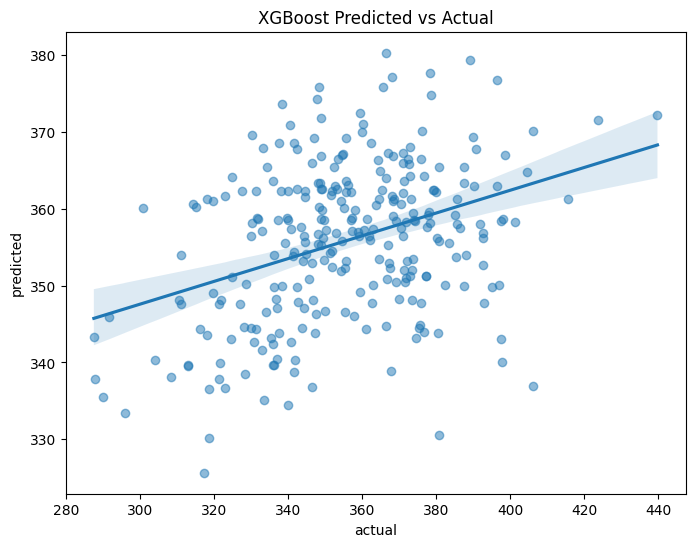

In [137]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [138]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2), ('kernel', 'poly')])


In [139]:
#gwas_snps = gwas_snps.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, tt_bbd_snps, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -8.104922047250136
RMSE for dataset is:23.349462200274978& mean of this fold is 355.89097272727275
this is 6.560846997984463% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -12.723766268418775
RMSE for dataset is:25.777557213895907& mean of this fold is 355.00728181818187
this is 7.261134780637532% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.895880109902607
RMSE for dataset is:19.21861011404249& mean of this fold is 353.1822545454545
this is 5.441555986094726% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -9.052570224062318
RMSE for dataset is:22.594744093718216& mean of this fold is 353.7732909090909
this is 6.386786304770641% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.945460891351087
RMSE for dat

In [140]:
pickle.dump(best_svr_model, open("xgboost_onlysnps_svr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -10.82
RMSE of Holdout: 23.25
Mean of Holdout: 355.60
This is 6.54% of the mean pheno data
0 355.712 352.69974174203236
1 344.136 354.88777994960583
2 351.481 359.7735013874536
3 353.611 359.77411078418794
4 390.342 360.7036967694147
5 358.958 351.69286962412275


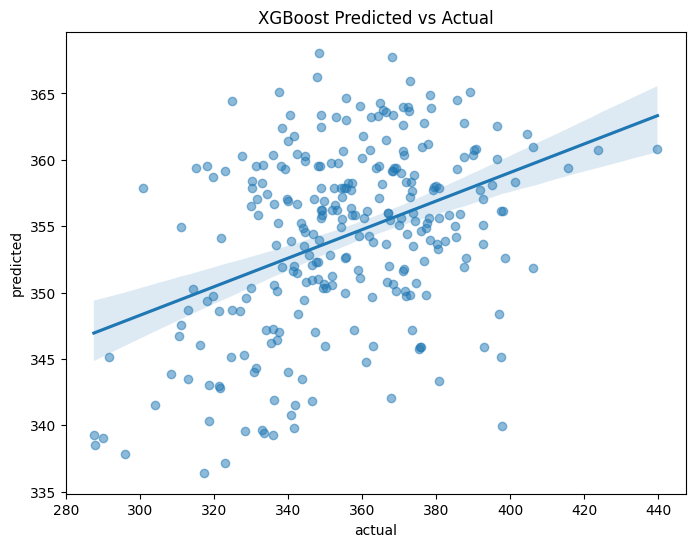

In [141]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

# GWAS only location

In [142]:
tt_loc= fs_data.drop(['BBD', 'LL',	'LW',	'PLH', 'PRT'], axis=1)
tt_loc.head()

,Chr18_23600020,Chr5_36248224,Chr3_37365271,Chr8_19012169,Chr8_11495742,Chr10_46415327,Chr13_5960542,Chr13_38932169,Chr15_52417374,Chr12_1111548,...,Chr18_7976151,Chr3_32202833,Chr3_40181839,Chr6_46052745,Chr15_44305656,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,2,0,0,0,2,0,2,0,0,...,0,0,0,1,0,1,0,0,0,1
s100,0,2,0,0,0,2,0,2,0,0,...,0,0,0,1,0,0,1,0,0,1
s1014,2,2,0,2,2,0,0,2,1,2,...,0,0,0,0,0,1,0,0,0,1
s1014,2,2,0,2,2,0,0,2,1,2,...,0,0,0,0,0,0,1,0,0,1
s101,0,0,0,0,0,2,2,0,0,0,...,0,0,0,0,0,0,0,1,0,1


In [143]:
tt_loc_dupe= fs_data.drop(['BBD', 'LL',	'LW',	'PLH', 'PRT'], axis=1)
tt_loc_dupe.head()

,Chr18_23600020,Chr5_36248224,Chr3_37365271,Chr8_19012169,Chr8_11495742,Chr10_46415327,Chr13_5960542,Chr13_38932169,Chr15_52417374,Chr12_1111548,...,Chr18_7976151,Chr3_32202833,Chr3_40181839,Chr6_46052745,Chr15_44305656,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,2,0,0,0,2,0,2,0,0,...,0,0,0,1,0,1,0,0,0,1
s100,0,2,0,0,0,2,0,2,0,0,...,0,0,0,1,0,0,1,0,0,1
s1014,2,2,0,2,2,0,0,2,1,2,...,0,0,0,0,0,1,0,0,0,1
s1014,2,2,0,2,2,0,0,2,1,2,...,0,0,0,0,0,0,1,0,0,1
s101,0,0,0,0,0,2,2,0,0,0,...,0,0,0,0,0,0,0,1,0,1


In [144]:
tt_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 1005 entries, Chr18_23600020 to landrace
dtypes: int64(1005)
memory usage: 8.4+ MB


In [145]:
tt_y = tt_data.iloc[:, 1009:]
tt_y.head()

,PRT
Line,
s100,340.553
s100,358.104
s1014,366.116
s1014,326.667
s101,385.915


In [146]:
# Run models

In [147]:
X_train, X_test, y_train, y_test = train_test_split(tt_loc, tt_y, test_size=0.1, random_state=42)

In [148]:
X_train.head()

,Chr18_23600020,Chr5_36248224,Chr3_37365271,Chr8_19012169,Chr8_11495742,Chr10_46415327,Chr13_5960542,Chr13_38932169,Chr15_52417374,Chr12_1111548,...,Chr18_7976151,Chr3_32202833,Chr3_40181839,Chr6_46052745,Chr15_44305656,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s174,0,2,0,2,2,0,0,0,1,0,...,0,0,1,0,0,0,1,0,1,0
s623,2,2,2,0,0,0,0,2,0,1,...,0,0,0,0,0,1,0,0,1,0
s237,0,2,2,0,0,2,2,1,0,2,...,0,0,0,0,0,1,0,0,1,0
s730,2,2,2,2,0,0,2,0,0,0,...,1,0,0,0,0,0,0,1,1,0
s195,0,2,2,0,0,2,0,0,0,2,...,0,0,0,0,0,0,0,1,1,0


In [149]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [150]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.2539054279115306), ('colsample_bytree', 0.4809576696342559), ('gamma', 3.169288611647266e-05), ('learning_rate', 0.052759557217512985), ('max_delta_step', 14), ('max_depth', 9), ('min_child_weight', 3), ('n_estimators', 138), ('reg_alpha', 2.873712301786629e-05), ('reg_lambda', 8.3570980818864e-09), ('subsample', 0.06877324348114687)])


In [151]:
tt_loc = tt_loc.to_numpy()
tt_y = tt_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, tt_loc, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.0478566286366036
RMSE for dataset is:18.888903700327447& mean of this fold is 354.55167272727283
this is 5.327546068258748% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.0158973510649307
RMSE for dataset is:21.29072176892003& mean of this fold is 353.1342454545453
this is 6.029073091315503% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.4479927390171414
RMSE for dataset is:23.964302395750867& mean of this fold is 359.706
this is 6.662191455174744% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.2190262988216691
RMSE for dataset is:20.07867935615732& mean of this fold is 355.2121545454546
this is 5.6525879250530995% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.714892366069513
RMSE for dataset is:

In [152]:
pickle.dump(best_xgbr_model, open("xgboost_onlyloc_xgbr_prt.pickle.dat", "wb"))
#best_xgbr_model = pickle.load(open("gwas_top1_onlyloc_xgbr_bbd.pickle.dat", "rb"))

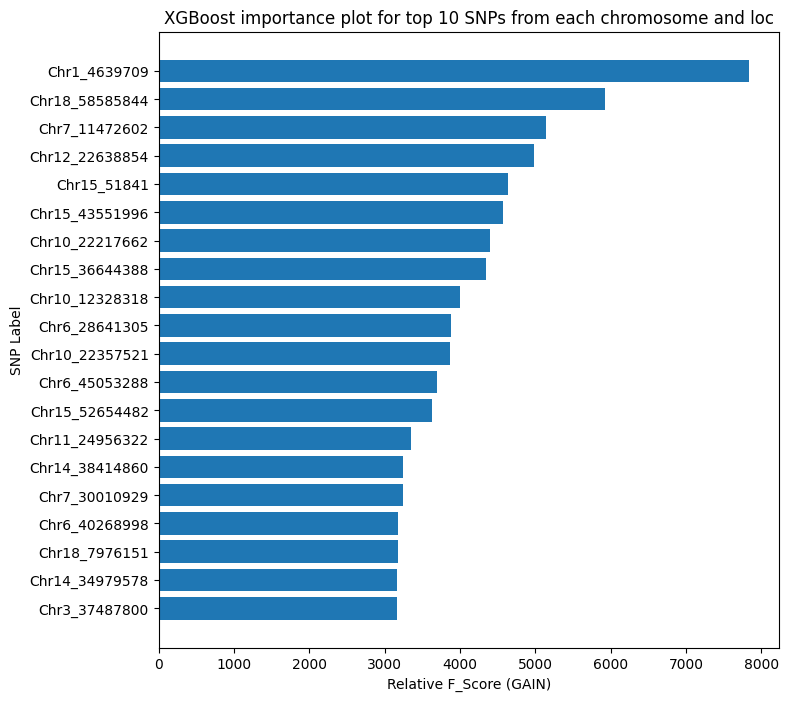

In [153]:
f_names = ['f' + str(i) for i in range(len(tt_loc_dupe.columns))]
my_dict = best_xgbr_model.get_booster().get_score(importance_type="gain")

new_dict = {}
for key in my_dict:
    ind = f_names.index(key)
    new_dict[tt_loc_dupe.columns[ind]] = my_dict[key]

new_fi = pd.Series(new_dict)
df = new_fi.to_frame()
df = df.rename(columns = {0:'F_Score(GAIN)'})

#plot dataframe now with top 20 SNPS
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
figure(num=None, figsize=(8, 8), dpi=100, facecolor='w', edgecolor='k')
indexes = df.nlargest(20, "F_Score(GAIN)").index
values = df.nlargest(20, "F_Score(GAIN)").values.ravel()
indexes = indexes[::-1]
values = values[::-1]
plt.barh(indexes, values)
plt.title('XGBoost importance plot for top 10 SNPs from each chromosome and loc')
plt.ylabel('SNP Label')
plt.xlabel('Relative F_Score (GAIN)')
plt.savefig('XGBoost importance plot for top 10 SNPs from each chromosome and loc.png')

In [154]:
explainer = shap.Explainer(best_xgbr_model)

In [155]:
shap_values = explainer(tt_loc_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

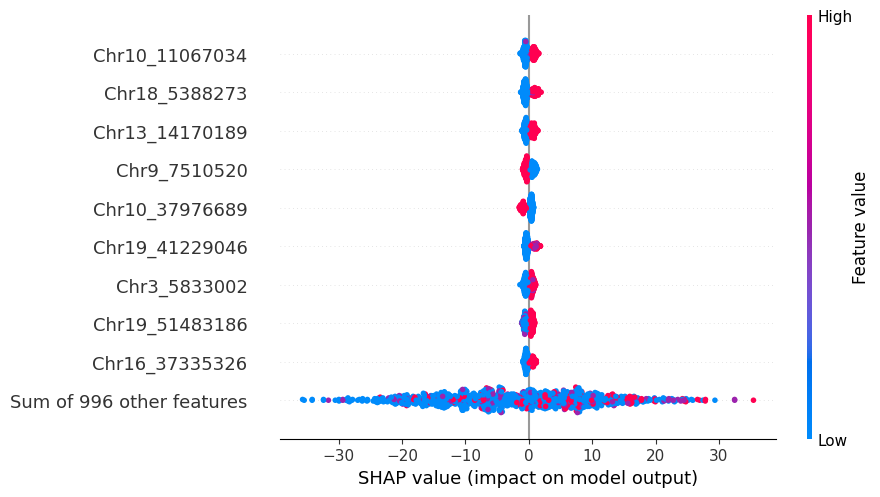

In [156]:
shap.plots.beeswarm(shap_values, show=False)

In [157]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [158]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102,2,0,0,0,0,0,0,1,0,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110,0,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112,0,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113,0,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [160]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [161]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [162]:
# Ensure both trainjg and holdout datasets have the same columns
tt_loc_dupe, X_holdout = tt_loc_dupe.align(X_holdout, join='inner', axis=1)

In [163]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 1005 entries, Chr18_23600020 to landrace
dtypes: int64(1005)
memory usage: 2.1+ MB


In [164]:
X_holdout.head()

,Chr18_23600020,Chr5_36248224,Chr3_37365271,Chr8_19012169,Chr8_11495742,Chr10_46415327,Chr13_5960542,Chr13_38932169,Chr15_52417374,Chr12_1111548,...,Chr18_7976151,Chr3_32202833,Chr3_40181839,Chr6_46052745,Chr15_44305656,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,0,0,0,2,2,0,0,0,...,0,0,0,0,0,1,0,0,0,1
s102,0,1,2,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
s110,2,0,0,0,2,0,0,2,1,0,...,1,0,0,0,0,1,0,0,0,1
s112,1,0,0,2,2,0,2,2,1,0,...,0,0,0,0,0,1,0,0,0,1
s113,2,0,0,2,2,0,0,0,1,0,...,1,0,2,0,1,1,0,0,0,1


In [165]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: -3.69
RMSE of Holdout: 23.86
Mean of Holdout: 355.60
This is 6.71% of the mean pheno data
0 355.712 359.7809
1 344.136 363.8713
2 351.481 366.4754
3 353.611 354.47623
4 390.342 360.19843
5 358.958 362.33868


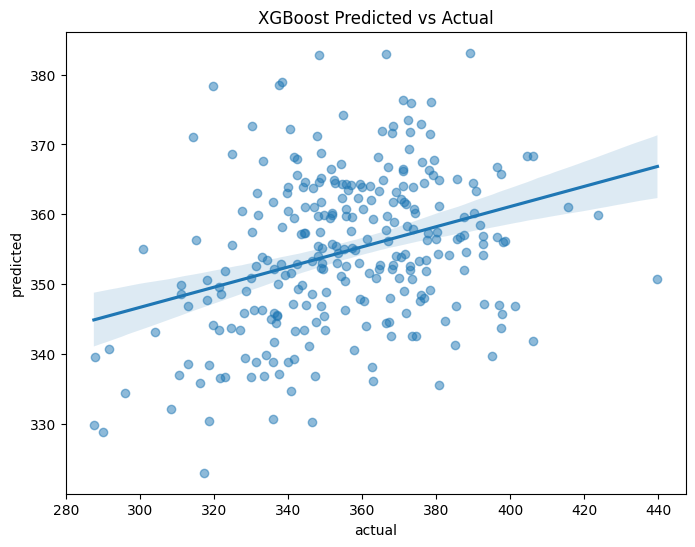

In [166]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [167]:
  # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])


0 355.712 359.7809
1 344.136 363.8713
2 351.481 366.4754
3 353.611 354.47623
4 390.342 360.19843
5 358.958 362.33868


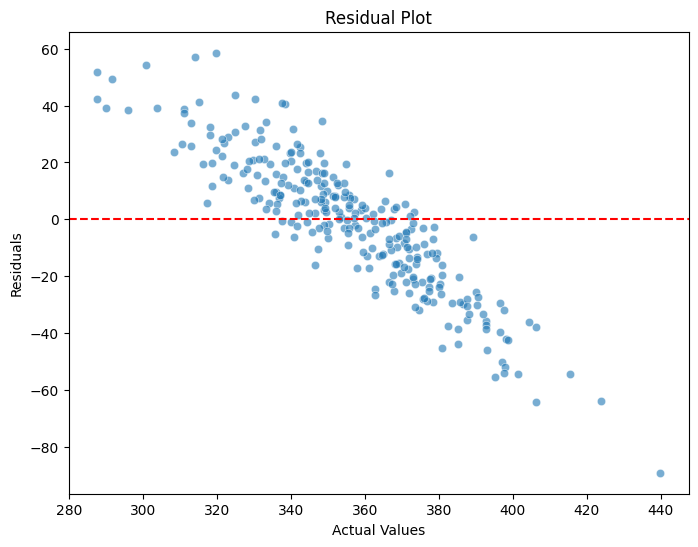

In [168]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot
plt.show()

In [169]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 12), ('max_features', 'sqrt'), ('max_samples', 0.5), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 495)])


In [170]:
#tt_loc = tt_loc.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, tt_loc, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.620641667055314
RMSE for dataset is:21.9161557762516& mean of this fold is 348.1884454545455
this is 6.294337466494896% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.6069265178584202
RMSE for dataset is:22.284317265812483& mean of this fold is 357.88532727272724
this is 6.226664120496528% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.1616016461050194
RMSE for dataset is:19.87331597747774& mean of this fold is 358.0521181818182
this is 5.550397545026144% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.656889609579387
RMSE for dataset is:21.90637704413942& mean of this fold is 351.7074454545455
this is 6.228579271566939% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.5781854694463244
RMSE for datas

In [171]:
pickle.dump(best_rfr_model, open("xgboost_onlyloc_rfr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -4.26
RMSE of Holdout: 23.25
Mean of Holdout: 355.60
This is 6.54% of the mean pheno data
0 355.712 354.3925598458193
1 344.136 354.0833925112655
2 351.481 365.1142928089365
3 353.611 365.55432813106927
4 390.342 361.8871941687016
5 358.958 353.0024395729194


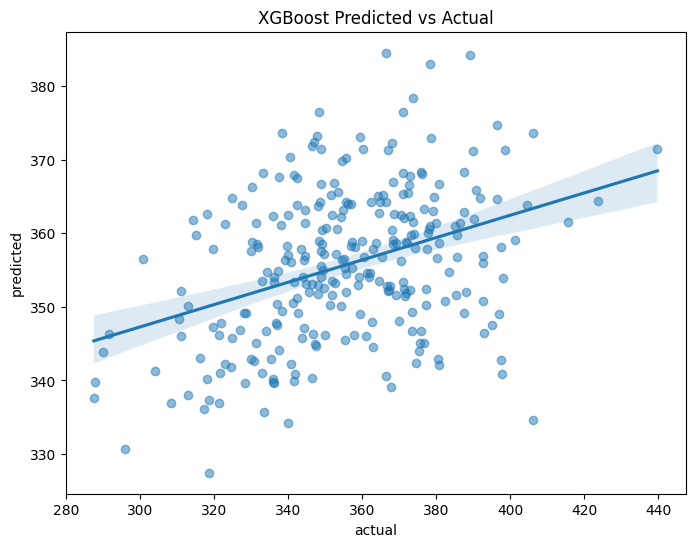

In [172]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [173]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2), ('kernel', 'poly')])


In [174]:
#gwas_loc = gwas_loc.to_numpy()
#gwas_y = gwas_y.to_numpy()
best_svr_model = eval_k_fold(best_svreg, tt_loc, tt_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.732579884317476
RMSE for dataset is:21.157683804102767& mean of this fold is 355.48756363636363
this is 5.9517367042818545% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -10.938229624970935
RMSE for dataset is:24.441424989222767& mean of this fold is 352.71170909090915
this is 6.929575729770613% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -8.11098833932277
RMSE for dataset is:20.887709758622538& mean of this fold is 351.92477272727274
this is 5.9352769049906176% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.874999188176995
RMSE for dataset is:20.629973279730688& mean of this fold is 355.2537363636364
this is 5.807109445462363% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -10.344854665678264
RMSE for

In [175]:
pickle.dump(best_svr_model, open("xgboost_onlyloc_svr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -10.42
RMSE of Holdout: 23.31
Mean of Holdout: 355.60
This is 6.55% of the mean pheno data
0 355.712 352.838874966295
1 344.136 355.420191384927
2 351.481 360.01395306181143
3 353.611 359.65101031286423
4 390.342 360.9672028238192
5 358.958 352.23222019772925


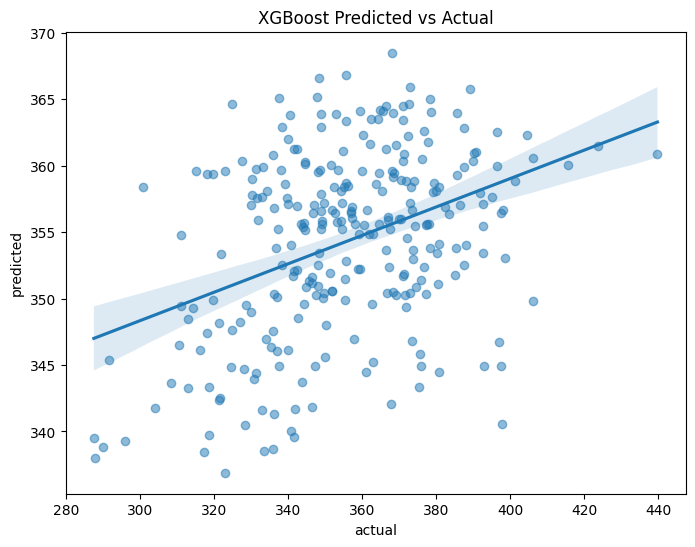

In [176]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)